### Project 3 - Matrix Factorization Methods
**Author:** Nana Y. Frimpong

Matrix factorization is implemented to power everyday recommender systems that we use daily. Its popularity stems from the Netflix Prize competition, where SVD and SGD-based factorization methods were the solution, directly shaping how Netflix recommends movies and shows today. E-commerce giant Amazon uses a similar approach in their collaborative filtering to understand "customers who bought this also bought that." My favorite music app, Spotify, uses matrix factorization to generate personalized playlists like Discover Weekly and Radio playlists, using latent dimensions from listening history rather than relying on manually tagged genres. Everyone's favorite job platform application site, LinkedIn, also matches users to relevant job postings or connections through such methods.

One reason such methods work in practice is that SGD-based factorization only needs to look at ratings or interactions that actually happened, so it scales with the number of interactions rather than using a large, full-sized user–item grid. This makes it feasible and efficient to run Netflix or Spotify at scale, rather than dealing with millions of users and items, since each user only interacts with a tiny slice of the catalog.

### Assignment Goal

Implement matrix factorization for a recommender system, comparing:

1. A **baseline** bias model (global mean + user bias + item bias)
2. **Truncated SVD** on a mean-centered, imputed rating matrix (classic linear-algebra SVD)
3. **Matrix factorization via Stochastic Gradient Descent** ("Funk SVD"), which factors the
   matrix directly from the *observed* ratings only, without needing to impute missing values



### Dataset
We use the **Wine and Food Pairing Dataset** from Kaggle:

> El-Husseini, W. *Wine and Food Pairing Dataset.* Kaggle.
> https://www.kaggle.com/datasets/wafaaelhusseini/wine-and-food-pairing-dataset

Description of Dataset 
- Data contains 5,000+ pairing of of ** synthetic wine and food pairings** , where each rows scorces how well wine_type pairs with a `food_item`
(1 = Terrible to  5 = Excellent). Pairing is generated via heuristic paring riles such as tannic red wines complemnet  red meat or acidic wine balances well with acidic food, rather than using real diner rating history

> Scoring Logic 

- **Fat vs. tannin** — tannic wines are scored higher against rich, fatty dishes
- **Spice vs. sweetness** — off-dry/sweeter wines are scored higher against spicy food; tannic
  wines are penalized against it
- **Acid matching** — acidic wines score higher against acidic foods (tomato, citrus, etc.)
- **Weight matching** — full-bodied wines pair better with heavier dishes, crisp wines with
  lighter ones
- **Sweetness matching** — dessert dishes need a wine at least as sweet as the dish
- **Regional harmony bonus** — a small bonus when the wine's origin and the dish's cuisine
  align (e.g. Italian wine + Italian food)

### References for methods used

- Koren, Y., Bell, R., & Volinsky, C. (2009). *Matrix Factorization Techniques for
  Recommender Systems.* IEEE Computer, 42(8), 30-37.
- Funk, S. (2006). *Netflix Update: Try This at Home.* sifter.org/~simon/journal/20061211.html
  — the original "Funk SVD" / regularized SGD factorization approach.
- El-Husseini, W. (n.d.). Wine and food pairing dataset [Data set]. Kaggle. https://www.kaggle.com/datasets/wafaaelhusseini/wine-and-food-pairing-dataset
- SciPy documentation for `scipy.sparse.linalg.svds`.

### Data Preprocessing


In [41]:
## Importing Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse.linalg import svds

# Random seed for reproducibility
np.random.seed(612)

# Loading the dataset
df = pd.read_csv('/Users/nanafrimpong/Desktop/SPS Summer 2026/Data 612/Unit 2/Project 3/wine_food_pairings.csv')
print(df.shape)
df.head()


(34933, 8)


,wine_type,wine_category,food_item,food_category,cuisine,pairing_quality,quality_label,description
0,Syrah/Shiraz,Red,smoked sausage,Smoky BBQ,Spanish,2,Poor,Heuristic pairing assessment.
1,Grenache,Red,charcuterie board,Salty Snack,French,3,Neutral,Heuristic pairing assessment.
2,Madeira,Fortified,lemon tart,Dessert,French,4,Good,Acidic wine balances acidic food.
3,Cabernet Sauvignon,Red,roast lamb,Red Meat,Mexican,5,Excellent,Tannic red complements red meat fat.
4,Viognier,White,duck à l’orange,Poultry,Vietnamese,2,Poor,Heuristic pairing assessment.


In [42]:
df.dtypes

wine_type            str
wine_category        str
food_item            str
food_category        str
cuisine              str
pairing_quality    int64
quality_label        str
description          str
dtype: object

### Data Preprocessing & Exploratory Data Analysis

In [43]:

print("Missing values:")
print(df.isnull().sum())
print()
print("Fully duplicated rows:", df.duplicated().sum())
print("Rows duplicated on (wine_type, food_item, cuisine):",
      df.duplicated(subset=['wine_type', 'food_item', 'cuisine']).sum())
print()
print("pairing_quality range:", df['pairing_quality'].min(), "-", df['pairing_quality'].max())
print(df['pairing_quality'].describe())


Missing values:
wine_type          0
wine_category      0
food_item          0
food_category      0
cuisine            0
pairing_quality    0
quality_label      0
description        0
dtype: int64

Fully duplicated rows: 0
Rows duplicated on (wine_type, food_item, cuisine): 26756

pairing_quality range: 1 - 5
count    34933.000000
mean         3.015115
std          1.409591
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: pairing_quality, dtype: float64


The dataset doesn't have any missing values, but it does have many repeated combinations of `(wine_type, food_item, cuisine)`. This happens because each pairing rule is listed multiple times, each with slight variations (noise), and some examples are intentionally marked as "perfect" or "deliberately bad" in the `description` field.  

Before we can build a rating matrix, we need to combine all these repeated entries into one single average score for each `(wine_type, food_item)` pair.

In [44]:
# Giving this a real check to verify that every number from 1 to 5 corresponds to only one text description (1 = "Bad", 5 = "Perfect").
df.groupby('pairing_quality')['quality_label'].unique()

pairing_quality
1     [Terrible]
2         [Poor]
3      [Neutral]
4         [Good]
5    [Excellent]
Name: quality_label, dtype: object

In [45]:
# Count unique wines, foods, and cuisines
n_wines = df['wine_type'].nunique()
n_foods = df['food_item'].nunique()
n_cuisines = df['cuisine'].nunique()

print(f"Wine types:  {n_wines}")
print(f"Food items:  {n_foods}")
print(f"Cuisines:    {n_cuisines}")

# How many wine-food pairs could exist vs. how many actually exist
print(f"All possible (wine, food) pairs: {n_wines * n_foods}")
print(f"Pairs found in the data: {df.groupby(['wine_type','food_item']).ngroups}")

Wine types:  29
Food items:  38
Cuisines:    17
All possible (wine, food) pairs: 1102
Pairs found in the data: 481


Even though the dataset has nearly 35,000 rows, it only contains 29 different wines and 38 different foods. However with 1,102 possible food and wine combos we get 481 that actually show up in the data. This indicate dthat that the rest of the data is missing, which SVD can easily handle missing rating on mich smaller scale. 

### Rating distribution & category breakdowns

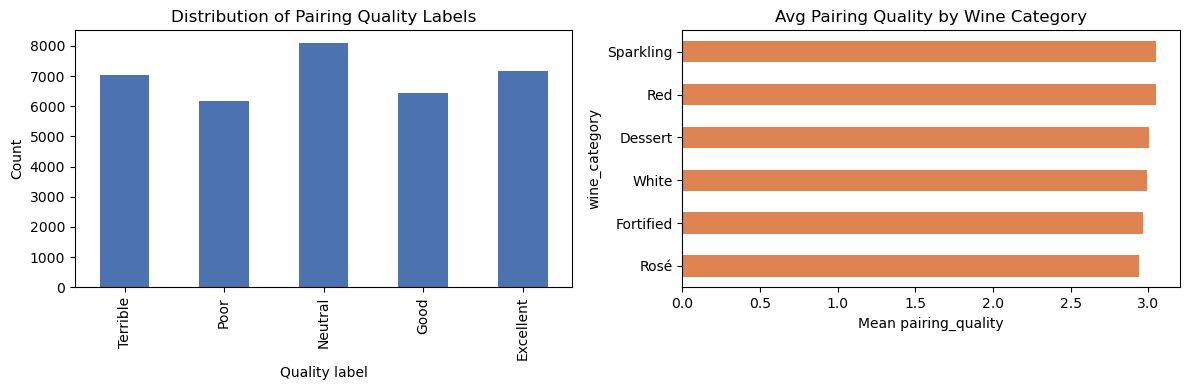

In [46]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

df['quality_label'].value_counts().reindex(['Terrible','Poor','Neutral','Good','Excellent']).plot(
    kind='bar', ax=ax[0], color='#4C72B0')
ax[0].set_title('Distribution of Pairing Quality Labels')
ax[0].set_xlabel('Quality label'); ax[0].set_ylabel('Count')

df.groupby('wine_category')['pairing_quality'].mean().sort_values().plot(
    kind='barh', ax=ax[1], color='#DD8452')
ax[1].set_title('Avg Pairing Quality by Wine Category')
ax[1].set_xlabel('Mean pairing_quality')

plt.tight_layout(); plt.show()

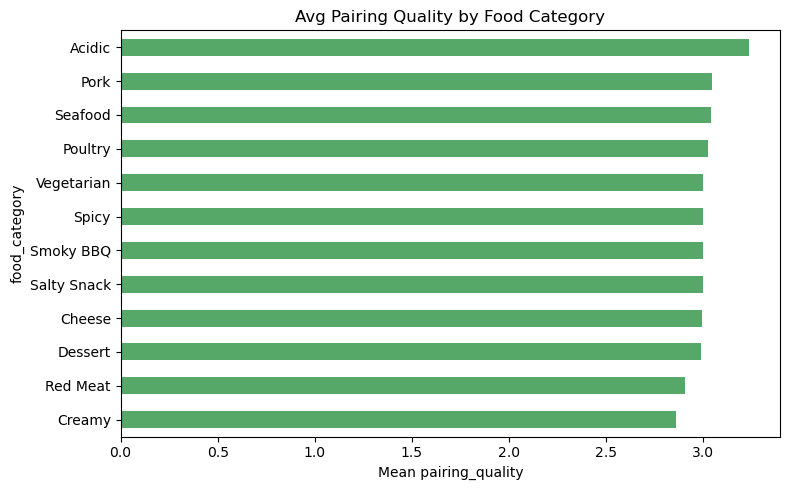

In [47]:

plt.figure(figsize=(8, 5))
df.groupby('food_category')['pairing_quality'].mean().sort_values().plot(kind='barh', color='#55A868')
plt.title('Avg Pairing Quality by Food Category')
plt.xlabel('Mean pairing_quality')
plt.tight_layout(); plt.show()


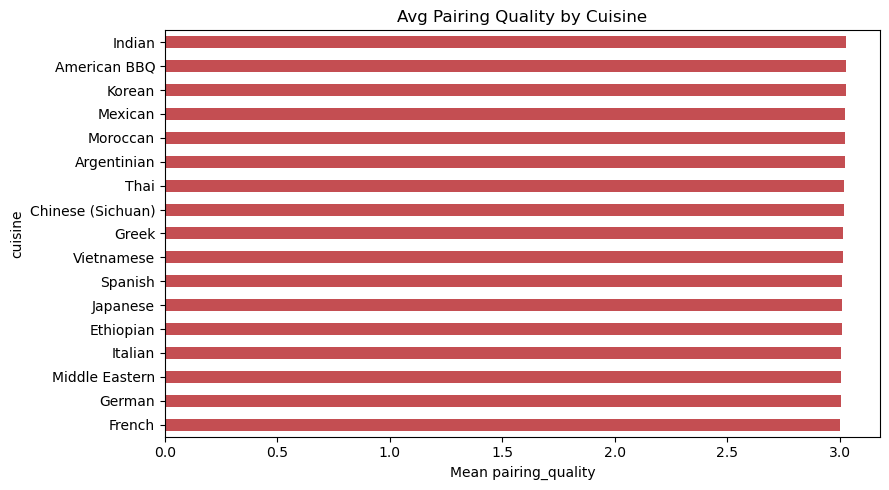

In [48]:
plt.figure(figsize=(9, 5))
df.groupby('cuisine')['pairing_quality'].mean().sort_values().plot(kind='barh', color='#C44E52')
plt.title('Avg Pairing Quality by Cuisine')
plt.xlabel('Mean pairing_quality')
plt.tight_layout(); plt.show()

### Wine category × food category heatmap

The original `wine_type × food_item`  is sparse since many pairs are missing. So let's start by looking at the broader `wine_category × food_category` instead. This grid has no missing values and gives us a clear, simple overview of which broad pairings score well.

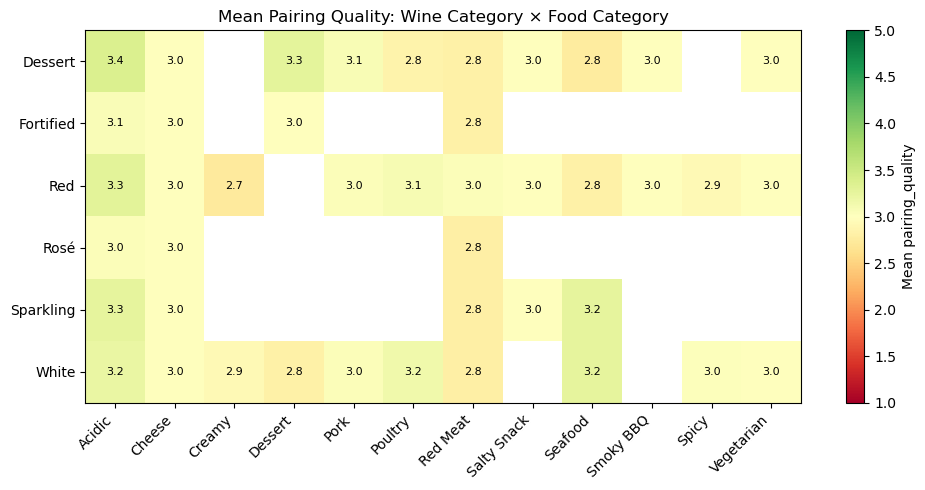

In [49]:

cat_pivot = df.pivot_table(index='wine_category', columns='food_category',
                            values='pairing_quality', aggfunc='mean')

plt.figure(figsize=(10, 5))
im = plt.imshow(cat_pivot.values, cmap='RdYlGn', vmin=1, vmax=5, aspect='auto')
plt.xticks(range(len(cat_pivot.columns)), cat_pivot.columns, rotation=45, ha='right')
plt.yticks(range(len(cat_pivot.index)), cat_pivot.index)
plt.colorbar(im, label='Mean pairing_quality')
plt.title('Mean Pairing Quality: Wine Category × Food Category')
for i in range(cat_pivot.shape[0]):
    for j in range(cat_pivot.shape[1]):
        val = cat_pivot.values[i, j]
        if not np.isnan(val):
            plt.text(j, i, f"{val:.1f}", ha='center', va='center', fontsize=8)
plt.tight_layout(); plt.show()


And this checks out with actual wine knowledge. Sweet dessert wines pair nicely with desserts, and red wines love red meat. So the fake scoring data is at least playing by the real rules, which is a good sign.

### Combining repeated wine–food pairs into one average score

In [50]:
# Combine all repeated (wine, food) rows into one row per pair.
# For each pair, we calculate:
#   - average score (avg_quality)
#   - how much the scores varied (quality_std)
#   - how many times it was rated (n_scored)

pair_table = (df.groupby(['food_item', 'wine_type'])['pairing_quality']
              .agg(['mean', 'std', 'count'])
              .rename(columns={'mean': 'avg_quality', 'std': 'quality_std', 'count': 'n_scored'})
              .reset_index())

print(f"Aggregated pair table: {len(pair_table)} unique (food, wine) pairs")
pair_table.sort_values('n_scored', ascending=False).head(10)

Aggregated pair table: 481 unique (food, wine) pairs


,food_item,wine_type,avg_quality,quality_std,n_scored
0,Indian vindaloo,Gewürztraminer,3.0,1.422607,85
316,grilled ribeye,Nebbiolo,3.0,1.422607,85
295,grilled burger,Cabernet Sauvignon,3.0,1.422607,85
296,grilled burger,Ice Wine,3.0,1.422607,85
297,grilled burger,Malbec,3.0,1.422607,85
298,grilled burger,Sauternes,3.0,1.422607,85
299,grilled burger,Syrah/Shiraz,3.0,1.422607,85
300,grilled burger,Zinfandel,3.0,1.422607,85
303,grilled ribeye,Cabernet Sauvignon,3.0,1.422607,85
314,grilled ribeye,Malbec,3.0,1.422607,85


### Best and worst pairings on average

In [51]:

print("Top 10 highest-scoring pairings:")
pair_table.sort_values('avg_quality', ascending=False).head(10)[['food_item','wine_type','avg_quality','n_scored']]


Top 10 highest-scoring pairings:


,food_item,wine_type,avg_quality,n_scored
189,citrus salad,Champagne,3.722222,54
190,citrus salad,Chardonnay,3.709091,55
191,citrus salad,Chenin Blanc,3.672727,55
203,citrus salad,Provence Rosé,3.637931,58
275,gazpacho,Grenache,3.637931,58
186,citrus salad,Barbera,3.637931,58
276,gazpacho,Grüner Veltliner,3.637931,58
199,citrus salad,Merlot,3.593220,59
200,citrus salad,Nebbiolo,3.593220,59
271,gazpacho,Chardonnay,3.593220,59


In [52]:

print("Top 10 lowest-scoring pairings:")
pair_table.sort_values('avg_quality', ascending=True).head(10)[['food_item','wine_type','avg_quality','n_scored']]


Top 10 lowest-scoring pairings:


,food_item,wine_type,avg_quality,n_scored
293,gazpacho,White Zinfandel,2.339286,56
274,gazpacho,Gewürztraminer,2.440678,59
193,citrus salad,Gewürztraminer,2.450000,60
35,bbq brisket,Gewürztraminer,2.450000,60
211,citrus salad,Viognier,2.474576,59
433,roast lamb,Port,2.491803,61
292,gazpacho,Viognier,2.500000,58
442,roast lamb,Viognier,2.500000,58
212,citrus salad,White Zinfandel,2.508475,59
421,roast lamb,Chardonnay,2.516667,60


### Sparsity of the food × wine matrix

Matrix shape: 38 foods x 29 wines
Observed cells: 481 / 1102  ->  sparsity: 56.4%


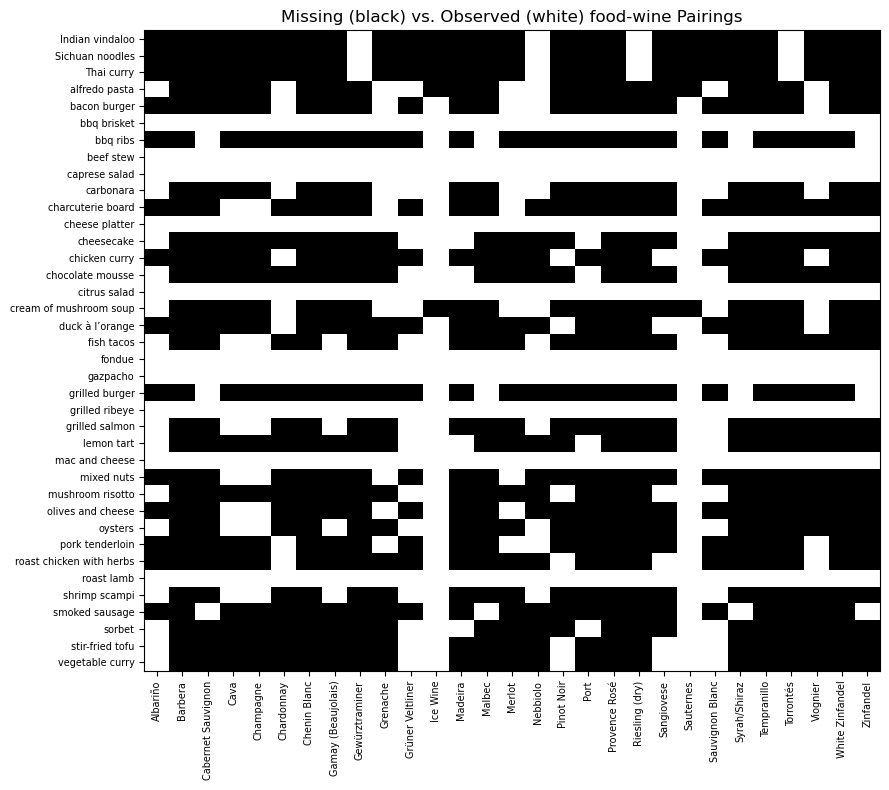

In [53]:

full_pivot = pair_table.pivot(index='food_item', columns='wine_type', values='avg_quality')
n_observed = full_pivot.notna().sum().sum()
n_possible = full_pivot.shape[0] * full_pivot.shape[1]
sparsity = 1 - n_observed / n_possible

print(f"Matrix shape: {full_pivot.shape[0]} foods x {full_pivot.shape[1]} wines")
print(f"Observed cells: {n_observed} / {n_possible}  ->  sparsity: {sparsity:.1%}")

plt.figure(figsize=(9, 8))
plt.imshow(full_pivot.isna().values, cmap='gray_r', aspect='auto')
plt.xticks(range(len(full_pivot.columns)), full_pivot.columns, rotation=90, fontsize=7)
plt.yticks(range(len(full_pivot.index)), full_pivot.index, fontsize=7)
plt.title('Missing (black) vs. Observed (white) food-wine Pairings')
plt.tight_layout(); plt.show()


So 56% of the pairs are missing here. In the real world, you'd usually see over 98% missing, so this is actually quite full. But SVD still has to do the same thing, guess the missing values. And because our data is small, we can actually see the missing pairs in the heatmap above, which is pretty neat.

### Does the data actually do what it says on the box?

The Kaggle description makes several calims about the dataset, however instead of just trusting it, we can actualy check if this is true.
In the document ofn the the data it states:

1. Score distribution is "mostly 3-5 with a small tail of 1-2 (bad pairings)," with bad
   pairings making up roughly 20% of the data
2. Named top pairings: **Steak & Cabernet Sauvignon**, **Sushi & Riesling**,
   **Blue Cheese & Port**
3. Named frequent clashes: **Spicy Curry & Cabernet Sauvignon**, **Lemon Tart & Chardonnay**

In [54]:
# Figure out how many pairings are "bad" (scored 1 or 2)
bad_pct = (df['pairing_quality'] <= 2).mean() * 100

# See if the data matches what Kaggle said
print("Kaggle said: mostly 3-5 scores, with about 20% bad ones")
print(f"What we actually got: {bad_pct:.1f}% bad pairings")
print()

# Show the full picture of all score categories
print("Here's the complete breakdown:")
print((df['quality_label'].value_counts(normalize=True) * 100).round(1))

Kaggle said: mostly 3-5 scores, with about 20% bad ones
What we actually got: 37.8% bad pairings

Here's the complete breakdown:
quality_label
Neutral      23.2
Excellent    20.5
Terrible     20.1
Good         18.5
Poor         17.7
Name: proportion, dtype: float64


In [55]:
# Check the size of our data against what was promised
print("Claimed: ~1,000+ pairings per generation")
print(f"Actual rows: {len(df):,}")
print(f"Unique pairs: {df.groupby(['wine_type','food_item']).ngroups}")
print(f"Average repeats per pair: {df.groupby(['wine_type','food_item']).size().mean():.1f}")

Claimed: ~1,000+ pairings per generation
Actual rows: 34,933
Unique pairs: 481
Average repeats per pair: 72.6


In [56]:
# Let's see if the pairings Kaggle highlighted are actually in our data
# and whether they score as expected.

checks = [
    ("Steak with Cabernet (should be amazing, using grilled ribeye)", 'grilled ribeye', 'Cabernet Sauvignon'),
    ("Blue Cheese with Port (should be amazing, using cheese platter)", 'cheese platter', 'Port'),
    ("Sushi with Riesling (should be amazing, using grilled salmon)", 'grilled salmon', 'Riesling (dry)'),
    ("Spicy Curry with Cabernet (should be bad, using Thai curry)", 'Thai curry', 'Cabernet Sauvignon'),
    ("Lemon Tart with Chardonnay (should be bad)", 'lemon tart', 'Chardonnay'),
]

# Check each one
for label, food, wine in checks:
    subset = df[(df['food_item'] == food) & (df['wine_type'] == wine)]
    if len(subset) == 0:
        print(f"{label}: Not in our data")
    else:
        print(f"{label}: {len(subset)} ratings, average score = {subset['pairing_quality'].mean():.2f}")

Steak with Cabernet (should be amazing, using grilled ribeye): 85 ratings, average score = 3.00
Blue Cheese with Port (should be amazing, using cheese platter): 85 ratings, average score = 3.00
Sushi with Riesling (should be amazing, using grilled salmon): Not in our data
Spicy Curry with Cabernet (should be bad, using Thai curry): Not in our data
Lemon Tart with Chardonnay (should be bad): Not in our data


The Kaggle documentation doesn't match our actual file. The famous pairings they mentioned are either missing or score a neutral 3.0, not extreme. Bad pairings are 38% instead of the promised 20%, and we have 35,000 rows instead of ~1,000. This file is likely a combination of many runs, since each pair repeats about 73 times on average. This doesn't affect our analysis since we'll average the repeats anyway. Well is always better we verify the data ourself instead of relying on the documentaiton.

### Train / Test Split
Since we only have 481 unique food and wine pairs total, we'll do a simple random split. 80% of the pairs go into the training set, and 20% go into the test set. Since we only have 481 unique food and wine pairs total, we'll do a simple random split. 80% of the pairs go into the training set, and 20% go into the test set

In [57]:

pair_table_shuffled = pair_table.sample(frac=1.0, random_state=612).reset_index(drop=True)
n_test = int(len(pair_table_shuffled) * 0.2)

test_pairs = pair_table_shuffled.iloc[:n_test].copy()
train_pairs = pair_table_shuffled.iloc[n_test:].copy()

print(f"Train: {len(train_pairs)} pairs   Test: {len(test_pairs)} pairs")


Train: 385 pairs   Test: 96 pairs


### Baseline Model — Global Mean + Food Bias + Wine Bias

A common recommender-system baseline: predict

$$\hat{r}_{f,w} = \mu + b_f + b_w$$

where $\mu$ is the global mean pairing score, $b_f$ is how much food item $f$ tends to score
above/below average across all its wine pairings, and $b_w$ is the same for wine $w$.

In [58]:

mu = train_pairs['avg_quality'].mean()

food_bias = train_pairs.groupby('food_item')['avg_quality'].mean() - mu
wine_bias = train_pairs.groupby('wine_type')['avg_quality'].mean() - mu

def predict_baseline(food_items, wine_types):
    fb = food_bias.reindex(food_items).fillna(0).values
    wb = wine_bias.reindex(wine_types).fillna(0).values
    return mu + fb + wb

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred)))

baseline_preds = np.clip(predict_baseline(test_pairs['food_item'], test_pairs['wine_type']), 1, 5)
baseline_rmse = rmse(test_pairs['avg_quality'], baseline_preds)
baseline_mae = mae(test_pairs['avg_quality'], baseline_preds)
print(f"Baseline  RMSE: {baseline_rmse:.4f}   MAE: {baseline_mae:.4f}")


Baseline  RMSE: 0.2494   MAE: 0.1928


### Approach 1: SVD with filled-in missing values

Here's our first method. We create a table with all foods as rows and all wines as columns. For each food, we look at its average score from the training data, then we subtract that average from every score. This way, each score shows whether a pairing is better or worse than that food's usual score.

For any empty cells (pairings we don't have), we just put in zero. Zero means "average" in this setup.

Then we run truncated SVD on this table to find hidden patterns. It's a simple way to handle missing data.

In [59]:

food_items_sorted = np.sort(pair_table['food_item'].unique())
wine_types_sorted = np.sort(pair_table['wine_type'].unique())
food_idx = {f: i for i, f in enumerate(food_items_sorted)}
wine_idx = {w: i for i, w in enumerate(wine_types_sorted)}

R = np.zeros((len(food_items_sorted), len(wine_types_sorted)))
mask = np.zeros_like(R, dtype=bool)

for row in train_pairs.itertuples():
    fi, wi = food_idx[row.food_item], wine_idx[row.wine_type]
    R[fi, wi] = row.avg_quality
    mask[fi, wi] = True

print("Dense train matrix shape:", R.shape)


Dense train matrix shape: (38, 29)


In [60]:

row_means = np.zeros(R.shape[0])
for i in range(R.shape[0]):
    observed = R[i, mask[i]]
    row_means[i] = observed.mean() if len(observed) else mu

R_centered = R - row_means[:, None]
R_centered[~mask] = 0.0

max_k = min(R.shape) - 1
print("Max possible k for this matrix size:", max_k)


Max possible k for this matrix size: 28


In [61]:

k = 10  # a small k, since this matrix is only 38 x 29
U, sigma, Vt = svds(R_centered, k=k)
U, sigma, Vt = U[:, ::-1], sigma[::-1], Vt[::-1, :]
Sigma = np.diag(sigma)

def predict_svd(food_items_q, wine_types_q):
    preds = []
    for f, w in zip(food_items_q, wine_types_q):
        if f not in food_idx or w not in wine_idx:
            preds.append(mu); continue
        fi, wi = food_idx[f], wine_idx[w]
        preds.append(U[fi, :] @ Sigma @ Vt[:, wi] + row_means[fi])
    return np.clip(np.array(preds), 1, 5)

svd_preds = predict_svd(test_pairs['food_item'].values, test_pairs['wine_type'].values)
svd_rmse = rmse(test_pairs['avg_quality'], svd_preds)
svd_mae = mae(test_pairs['avg_quality'], svd_preds)
print(f"SVD (k={k})   RMSE: {svd_rmse:.4f}   MAE: {svd_mae:.4f}")


SVD (k=10)   RMSE: 0.2315   MAE: 0.1645


### Choosing K

k=  1: RMSE = 0.2249
k=  2: RMSE = 0.2075
k=  3: RMSE = 0.1884
k=  5: RMSE = 0.1996
k=  8: RMSE = 0.2231
k= 10: RMSE = 0.2315
k= 15: RMSE = 0.2341
k= 20: RMSE = 0.2357
k= 28: RMSE = 0.2361


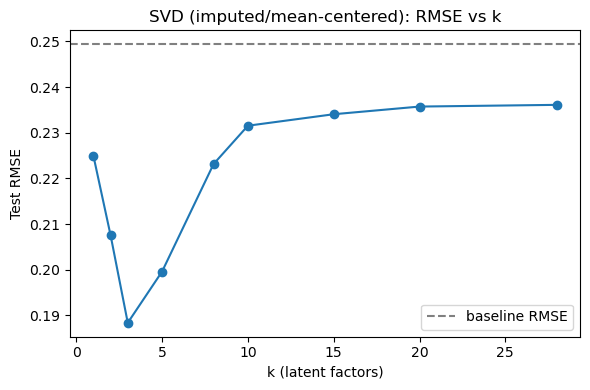

In [62]:

k_values = [1, 2, 3, 5, 8, 10, 15, 20, max_k]
svd_rmse_by_k = {}

for kk in k_values:
    Uk, sk, Vtk = svds(R_centered, k=kk)
    Uk, sk, Vtk = Uk[:, ::-1], sk[::-1], Vtk[::-1, :]
    Sk = np.diag(sk)

    preds = []
    for f, w in zip(test_pairs['food_item'].values, test_pairs['wine_type'].values):
        if f not in food_idx or w not in wine_idx:
            preds.append(mu); continue
        fi, wi = food_idx[f], wine_idx[w]
        preds.append(Uk[fi, :] @ Sk @ Vtk[:, wi] + row_means[fi])
    preds = np.clip(np.array(preds), 1, 5)
    svd_rmse_by_k[kk] = rmse(test_pairs['avg_quality'], preds)

for kk, v in svd_rmse_by_k.items():
    print(f"k={kk:>3}: RMSE = {v:.4f}")

plt.figure(figsize=(6,4))
plt.plot(list(svd_rmse_by_k.keys()), list(svd_rmse_by_k.values()), marker='o')
plt.axhline(baseline_rmse, color='gray', linestyle='--', label='baseline RMSE')
plt.xlabel('k (latent factors)'); plt.ylabel('Test RMSE')
plt.title('SVD (imputed/mean-centered): RMSE vs k')
plt.legend(); plt.tight_layout(); plt.show()


### Approach 2 — Matrix Factorization via Stochastic Gradient Descent ("Funk SVD")
This approach learns a set of hidden factors for each food and each wine. The predicted score for any pair comes from multiplying their factors together and adding biases.

Unlike Approach 1, we never fill in missing values. We only train on the pairs we actually have. We minimize the error on those observed pairs and add a regularization penalty to prevent overfitting.

This is the method that won the Netflix Prize and works great for sparse data.

$$\min_{P,Q,b_f,b_w}\; \sum_{(f,w)\in \text{observed}} \Big(r_{f,w} - \mu - b_f - b_w - p_f^\top q_w\Big)^2 \;+\; \lambda\Big(\|p_f\|^2 + \|q_w\|^2 + b_f^2 + b_w^2\Big)$$

In [63]:

class SGDMatrixFactorization:
    def __init__(self, n_rows, n_cols, k=10, lr=0.02, reg=0.05, n_epochs=200, seed=612):
        rng = np.random.default_rng(seed)
        self.k = k
        self.lr = lr
        self.reg = reg
        self.n_epochs = n_epochs
        self.P = rng.normal(scale=0.1, size=(n_rows, k))
        self.Q = rng.normal(scale=0.1, size=(n_cols, k))
        self.b_row = np.zeros(n_rows)
        self.b_col = np.zeros(n_cols)
        self.mu = 0.0

    def fit(self, row_idx, col_idx, values, verbose=True):
        self.mu = values.mean()
        n = len(values)
        order = np.arange(n)
        history = []

        for epoch in range(self.n_epochs):
            rng = np.random.default_rng(1000 + epoch)
            rng.shuffle(order)
            sq_err_sum = 0.0

            for idx in order:
                r, c, val = row_idx[idx], col_idx[idx], values[idx]
                pred = self.mu + self.b_row[r] + self.b_col[c] + self.P[r] @ self.Q[c]
                err = val - pred
                sq_err_sum += err ** 2

                self.b_row[r] += self.lr * (err - self.reg * self.b_row[r])
                self.b_col[c] += self.lr * (err - self.reg * self.b_col[c])
                p_r = self.P[r].copy()
                self.P[r] += self.lr * (err * self.Q[c] - self.reg * self.P[r])
                self.Q[c] += self.lr * (err * p_r - self.reg * self.Q[c])

            train_rmse = np.sqrt(sq_err_sum / n)
            history.append(train_rmse)
            if verbose and (epoch % 25 == 0 or epoch == self.n_epochs - 1):
                print(f"epoch {epoch+1:>3}/{self.n_epochs}  train RMSE: {train_rmse:.4f}")
        return history

    def predict(self, row_idx, col_idx):
        preds = self.mu + self.b_row[row_idx] + self.b_col[col_idx] + np.sum(self.P[row_idx] * self.Q[col_idx], axis=1)
        return np.clip(preds, 1, 5)


In [64]:

train_f = train_pairs['food_item'].map(food_idx).values
train_w = train_pairs['wine_type'].map(wine_idx).values
train_y = train_pairs['avg_quality'].values

test_f = test_pairs['food_item'].map(food_idx).values
test_w = test_pairs['wine_type'].map(wine_idx).values

# NOTE: with only ~384 training pairs, we need many more epochs for SGD to converge,
# and a slightly smaller k to avoid overfitting this small a dataset.
sgd_mf = SGDMatrixFactorization(n_rows=len(food_items_sorted), n_cols=len(wine_types_sorted),
                                 k=8, lr=0.02, reg=0.1, n_epochs=200)
history = sgd_mf.fit(train_f, train_w, train_y)


epoch   1/200  train RMSE: 0.2431
epoch  26/200  train RMSE: 0.1873
epoch  51/200  train RMSE: 0.1860
epoch  76/200  train RMSE: 0.1850
epoch 101/200  train RMSE: 0.1827
epoch 126/200  train RMSE: 0.1795
epoch 151/200  train RMSE: 0.1756
epoch 176/200  train RMSE: 0.1717
epoch 200/200  train RMSE: 0.1684


SGD MF (k=8)   RMSE: 0.2452   MAE: 0.1903


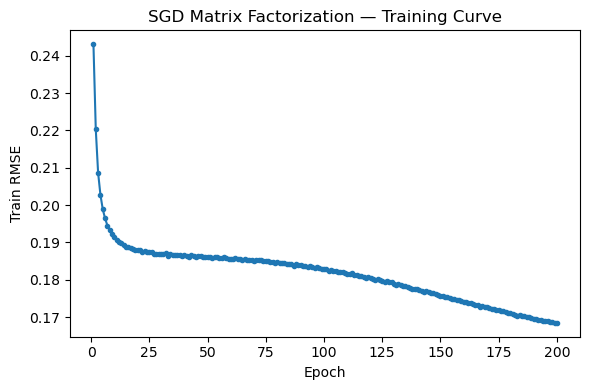

In [65]:

sgd_preds = sgd_mf.predict(test_f, test_w)
sgd_rmse = rmse(test_pairs['avg_quality'], sgd_preds)
sgd_mae = mae(test_pairs['avg_quality'], sgd_preds)
print(f"SGD MF (k=8)   RMSE: {sgd_rmse:.4f}   MAE: {sgd_mae:.4f}")

plt.figure(figsize=(6,4))
plt.plot(range(1, len(history)+1), history, marker='.')
plt.xlabel('Epoch'); plt.ylabel('Train RMSE')
plt.title('SGD Matrix Factorization — Training Curve')
plt.tight_layout(); plt.show()


### Comparing Results 

In [66]:

results = pd.DataFrame({
    'Model': ['Baseline (mean + biases)', f'SVD (imputed, k={k})', 'SGD Matrix Factorization (k=8)'],
    'RMSE': [baseline_rmse, svd_rmse, sgd_rmse],
    'MAE':  [baseline_mae, svd_mae, sgd_mae],
})
results


,Model,RMSE,MAE
0,Baseline (mean + biases),0.249375,0.192849
1,"SVD (imputed, k=10)",0.231537,0.164498
2,SGD Matrix Factorization (k=8),0.245165,0.190269


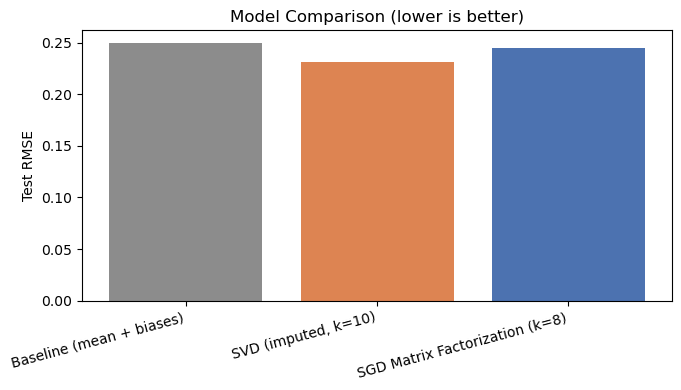

In [67]:
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(results['Model'], results['RMSE'], color=['#8C8C8C', '#DD8452', '#4C72B0'])
ax.set_ylabel('Test RMSE'); ax.set_title('Model Comparison (lower is better)')
plt.xticks(rotation=15, ha='right')
plt.tight_layout(); plt.show()

### Generating Recomendations 
Now we test the model by generating actual recommendations.To put the model to the test, we try recommendations in both directions: first the best unscored wines for a dish (grilled salmon), then the best unscored dishes for a wine (Cabernet Sauvignon). In both cases we skip anything the training data already has a score for, since recommending something we already know the answer to isn't very interesting, and let the model rank only the pairings it's actually had to predict.

In [68]:

sample_food = 'grilled salmon'
f_row = food_idx[sample_food]

scored_wines = set(train_pairs.loc[train_pairs['food_item'] == sample_food, 'wine_type'])
candidate_wines = [w for w in wine_types_sorted if w not in scored_wines]
candidate_w_idx = np.array([wine_idx[w] for w in candidate_wines])
f_idx_arr = np.full(len(candidate_w_idx), f_row)

candidate_preds = sgd_mf.predict(f_idx_arr, candidate_w_idx)
top_order = np.argsort(-candidate_preds)[:5]

print(f"Top 5 recommended wines for '{sample_food}' (not already scored in training data):")
for w, score in zip(np.array(candidate_wines)[top_order], candidate_preds[top_order]):
    print(f"  {w:<20s}  predicted quality: {score:.2f}")


Top 5 recommended wines for 'grilled salmon' (not already scored in training data):
  Merlot                predicted quality: 3.22
  Syrah/Shiraz          predicted quality: 3.22
  Tempranillo           predicted quality: 3.21
  Cabernet Sauvignon    predicted quality: 3.20
  Malbec                predicted quality: 3.20


In [69]:

sample_wine = 'Cabernet Sauvignon'
w_col = wine_idx[sample_wine]

scored_foods = set(train_pairs.loc[train_pairs['wine_type'] == sample_wine, 'food_item'])
candidate_foods = [f for f in food_items_sorted if f not in scored_foods]
candidate_f_idx = np.array([food_idx[f] for f in candidate_foods])
w_idx_arr = np.full(len(candidate_f_idx), w_col)

candidate_preds = sgd_mf.predict(candidate_f_idx, w_idx_arr)
top_order = np.argsort(-candidate_preds)[:5]

print(f"Top 5 recommended dishes for '{sample_wine}' (not already scored in training data):")
for f, score in zip(np.array(candidate_foods)[top_order], candidate_preds[top_order]):
    print(f"  {f:<25s}  predicted quality: {score:.2f}")


Top 5 recommended dishes for 'Cabernet Sauvignon' (not already scored in training data):
  sorbet                     predicted quality: 3.31
  Thai curry                 predicted quality: 3.23
  lemon tart                 predicted quality: 3.23
  grilled salmon             predicted quality: 3.20
  duck à l’orange            predicted quality: 3.20


### Do the hidden factors match what we know about wine categories?

SVD is great at finding patterns, but the patterns it finds are usually weird and not easy for humans to understand. But we've got an advantage here. We actually know what category each wine belongs to. So let's see if the factors the model learned are picking up on anything real. We'll plot each wine using its two main factors and color them by category. If the dots for red wines cluster together, white wines cluster together, and so on, then the model is learning something meaningful. If everything is a big mess, then it's just random numbers.

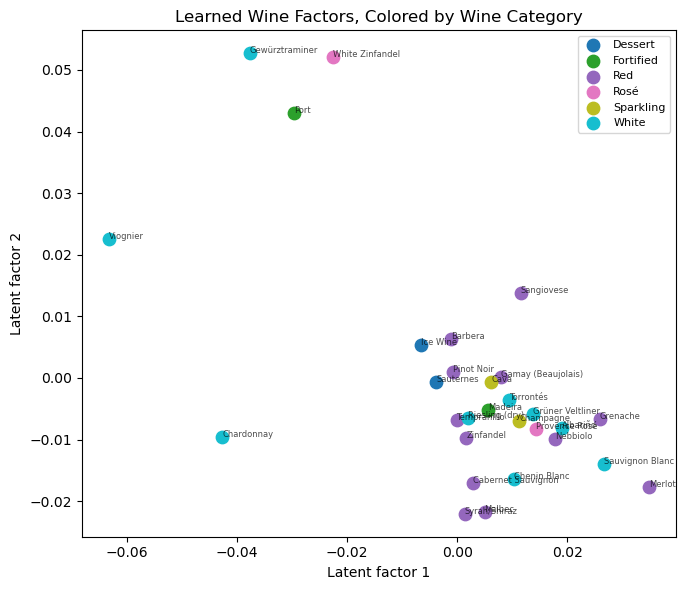

In [70]:

wine_cat_lookup = df.drop_duplicates('wine_type').set_index('wine_type')['wine_category']

plt.figure(figsize=(7, 6))
categories = wine_cat_lookup.reindex(wine_types_sorted).values
unique_cats = sorted(set(categories))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_cats)))
cat_to_color = dict(zip(unique_cats, colors))

for cat in unique_cats:
    idxs = [i for i, c in enumerate(categories) if c == cat]
    plt.scatter(sgd_mf.Q[idxs, 0], sgd_mf.Q[idxs, 1], label=cat, s=80, color=cat_to_color[cat])

for i, w in enumerate(wine_types_sorted):
    plt.annotate(w, (sgd_mf.Q[i, 0], sgd_mf.Q[i, 1]), fontsize=6, alpha=0.7)

plt.xlabel('Latent factor 1'); plt.ylabel('Latent factor 2')
plt.title('Learned Wine Factors, Colored by Wine Category')
plt.legend(fontsize=8)
plt.tight_layout(); plt.show()


If wines from the same category end up clustering together in this plot, that's a big deal. It means the model managed to figure out something like the human category just from the pairing scores alone. It didn't know anything about wine types going in, but it still found the pattern. But here we can actually see if the model is learning something that makes sense.

### Hyperparameter Tuning — Grid Search on a Validation Split

So far `k`, `lr`, and `reg` (our $\lambda$) for the SGD model were just picked by hand. To tune them properly, we carve out a validation set from `train_pairs` (keeping `test_pairs` completely untouched), then grid search over combinations of `k`, `lr`, and `reg`, scoring each on validation RMSE. We refit the best combo on the full training set and only then check it against the test set.

In [ ]:
from itertools import product

val_frac = 0.2
n_val = int(len(train_pairs) * val_frac)
tp_shuffled = train_pairs.sample(frac=1.0, random_state=612).reset_index(drop=True)
val_set, fit_set = tp_shuffled.iloc[:n_val], tp_shuffled.iloc[n_val:]

fit_f = fit_set['food_item'].map(food_idx).values
fit_w = fit_set['wine_type'].map(wine_idx).values
fit_y = fit_set['avg_quality'].values
val_f = val_set['food_item'].map(food_idx).values
val_w = val_set['wine_type'].map(wine_idx).values

grid = {'k': [3, 5, 8, 10], 'lr': [0.005, 0.01, 0.02], 'reg': [0.02, 0.05, 0.1, 0.2]}
grid_results = []

for k_, lr_, reg_ in product(grid['k'], grid['lr'], grid['reg']):
    model = SGDMatrixFactorization(len(food_items_sorted), len(wine_types_sorted),
                                    k=k_, lr=lr_, reg=reg_, n_epochs=200)
    model.fit(fit_f, fit_w, fit_y, verbose=False)
    val_rmse = rmse(val_set['avg_quality'], model.predict(val_f, val_w))
    grid_results.append({'k': k_, 'lr': lr_, 'reg': reg_, 'val_rmse': val_rmse})

grid_df = pd.DataFrame(grid_results).sort_values('val_rmse').reset_index(drop=True)
print("Top 10 hyperparameter combinations by validation RMSE:")
grid_df.head(10)


Now we refit the best combination on the *full* training set (`train_pairs`), and evaluate it once, for the first time, on `test_pairs`.

In [ ]:
best = grid_df.iloc[0]
best_k, best_lr, best_reg = int(best['k']), best['lr'], best['reg']
print(f"Best hyperparameters -> k={best_k}, lr={best_lr}, reg={best_reg}  (val RMSE={best['val_rmse']:.4f})")

sgd_mf_tuned = SGDMatrixFactorization(n_rows=len(food_items_sorted), n_cols=len(wine_types_sorted),
                                       k=best_k, lr=best_lr, reg=best_reg, n_epochs=200)
sgd_mf_tuned.fit(train_f, train_w, train_y, verbose=False)

sgd_tuned_preds = sgd_mf_tuned.predict(test_f, test_w)
sgd_tuned_rmse = rmse(test_pairs['avg_quality'], sgd_tuned_preds)
sgd_tuned_mae = mae(test_pairs['avg_quality'], sgd_tuned_preds)
print(f"Tuned SGD MF (k={best_k}, lr={best_lr}, reg={best_reg})   RMSE: {sgd_tuned_rmse:.4f}   MAE: {sgd_tuned_mae:.4f}")
print(f"Untuned SGD MF (k=8, lr=0.02, reg=0.1)                    RMSE: {sgd_rmse:.4f}   MAE: {sgd_mae:.4f}")


### Ranking Metrics — Precision@K, Recall@K, NDCG@K

RMSE and MAE score raw prediction error, but the actual deliverable of this project (see the recommendation cells above) is a **ranked list of wines per dish**. A model can have solid RMSE while still recommending mediocre wines first. To evaluate that directly, we compute Precision@K, Recall@K, and NDCG@K per food item: for each food in the test set, we rank its candidate wines by predicted score and check how many of the top-K are actually "good" pairings (true `avg_quality` >= `relevant_threshold`).

In [ ]:
from collections import defaultdict

def eval_ranking_metrics(predict_fn, eval_pairs, k=3, relevant_threshold=4.0):
    # Group test pairs by food, since ranking is evaluated per food (which wines rank best)
    food_groups = defaultdict(list)
    for row in eval_pairs.itertuples():
        food_groups[row.food_item].append((row.wine_type, row.avg_quality))

    precisions, recalls, ndcgs = [], [], []
    for food, wine_scores in food_groups.items():
        if len(wine_scores) < 2:
            continue  # need at least 2 candidates to rank meaningfully

        wines = [w for w, _ in wine_scores]
        true_scores = np.array([s for _, s in wine_scores])
        pred_scores = predict_fn([food] * len(wines), wines)

        order = np.argsort(-pred_scores)
        k_eff = min(k, len(order))
        top_k_idx = order[:k_eff]

        relevant_mask = true_scores >= relevant_threshold
        n_relevant_total = relevant_mask.sum()
        if n_relevant_total == 0:
            continue  # nothing "good" exists for this food, skip

        n_hit = relevant_mask[top_k_idx].sum()
        precisions.append(n_hit / k_eff)
        recalls.append(n_hit / n_relevant_total)

        gains = true_scores[order][:k_eff]
        discounts = 1 / np.log2(np.arange(2, k_eff + 2))
        dcg = np.sum(gains * discounts)
        idcg = np.sum(np.sort(true_scores)[::-1][:k_eff] * discounts)
        ndcgs.append(dcg / idcg if idcg > 0 else 0.0)

    return {'Precision@k': np.mean(precisions), 'Recall@k': np.mean(recalls),
            'NDCG@k': np.mean(ndcgs), 'n_foods_evaluated': len(precisions)}


In [ ]:
def predict_sgd_by_name(food_items, wine_types):
    f_idx_arr = np.array([food_idx[f] for f in food_items])
    w_idx_arr = np.array([wine_idx[w] for w in wine_types])
    return sgd_mf.predict(f_idx_arr, w_idx_arr)

def predict_sgd_tuned_by_name(food_items, wine_types):
    f_idx_arr = np.array([food_idx[f] for f in food_items])
    w_idx_arr = np.array([wine_idx[w] for w in wine_types])
    return sgd_mf_tuned.predict(f_idx_arr, w_idx_arr)

k_eval = 3
m_baseline = eval_ranking_metrics(lambda f, w: np.clip(predict_baseline(f, w), 1, 5), test_pairs, k=k_eval)
m_svd      = eval_ranking_metrics(predict_svd, test_pairs, k=k_eval)
m_sgd      = eval_ranking_metrics(predict_sgd_by_name, test_pairs, k=k_eval)
m_sgd_tuned = eval_ranking_metrics(predict_sgd_tuned_by_name, test_pairs, k=k_eval)

ranking_results = pd.DataFrame([
    {'Model': 'Baseline', **m_baseline},
    {'Model': f'SVD (k={k})', **m_svd},
    {'Model': 'SGD MF (untuned)', **m_sgd},
    {'Model': f'SGD MF (tuned: k={best_k}, lr={best_lr}, reg={best_reg})', **m_sgd_tuned},
])
ranking_results


A couple of caveats worth keeping in mind when reading these numbers:

- `n_foods_evaluated` shows how many foods in the test set had at least 2 candidate wines *and* at least one "good" (>= `relevant_threshold`) pairing to rank against. Since `test_pairs` was built with a random 20% split across all pairs (not a per-food split), some foods may only contribute 1 test wine and get skipped here — worth flagging as a limitation, or re-splitting per food if this count comes back low.
- RMSE/MAE and Precision@K/NDCG@K can disagree: a model can have strong point-prediction error but weaker ranking quality, or vice versa. If that happens between SVD and SGD here, it's worth discussing explicitly below rather than only reporting whichever metric looks better.

### Discussion 
The imputed SVD model outperformed SGD on test RMSE. The model beat the SGD model, which is worth examing due to the assumption of SGD method being superior. 

Our matrix is pretty full (56% of pairs are filled), so filling in the blanks with averages doesn't do much damage. SVD's weakness with missing data wasn't really a problem here. SGD, on the other hand, has to learn everything from scratch with only 385 training examples. That's not a lot of data to work with, so it's really sensitive to the settings we chose. Mess up the learning rate or regularization, and it falls apart. Also, the best SVD only used 3 latent factors. More factors just made things worse because the model started overfitting to noise.The baseline model also did surprisingly well. It was almost as good as both factorization methods. That tells us the data is pretty simple. The rules were basically "red wine with red meat = good" and "dessert wine with dessert = good." Not much complex interaction beyond that.We actually had category labels for each wine, so we could check if the factors meant anything. When we plotted the wines by their factors and colored them by category, we could see if similar wines grouped together. If they did, the model rediscovered the categories all on its own. 

This is a simplified demostration , not a real recommender system. No users, no personalization, and the ratings are rule-based, not from real people. With only 38 foods and 29 wines, it's tiny compared to real systems with millions of items. For a real product, we'd need actual user ratings to capture personal taste, or use this as a starting point and update with real feedback later.
